## What I've done here;

Loading and cleaning real F1 data
Handling hidden null values
Merging datasets
Groupby and aggregation
Scatter plot with overplotting fix
Correlation analysis
Segmenting data to compare eras

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)

pandas: 3.0.2
numpy: 2.4.4
matplotlib: 3.10.8
seaborn: 0.13.2


In [3]:
import pandas as pd

df = pd.read_csv("data/results.csv")

print(df.shape)
print(df.head())

(26759, 18)
   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   
3         4      18         4              4      5    11        4   
4         5      18         5              1     23     3        5   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34:50.616      5690616   
1            2              2     8.0    58       +5.478      5696094   
2            3              3     6.0    58       +8.163      5698779   
3            4              4     5.0    58      +17.181      5707797   
4            5              5     4.0    58      +18.014      5708630   

  fastestLap rank fastestLapTime fastestLapSpeed  statusId  
0         39    2       1:27.452         218.300         1  
1     

In [4]:
print(df.dtypes)
print("\n")
print(df.isnull().sum())

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number                 str
grid                 int64
position               str
positionText           str
positionOrder        int64
points             float64
laps                 int64
time                   str
milliseconds           str
fastestLap             str
rank                   str
fastestLapTime         str
fastestLapSpeed        str
statusId             int64
dtype: object


resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64


In [5]:
print(df['position'].unique())

<StringArray>
[ '1',  '2',  '3',  '4',  '5',  '6',  '7',  '8', '\N',  '9', '10', '11', '12',
 '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
 '26', '27', '28', '29', '30', '31', '32', '33']
Length: 34, dtype: str


In [6]:
df = pd.read_csv("data/results.csv", na_values="\\N")
print(df.isnull().sum())

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64


In [7]:
total = len(df)
has_position = df['position'].notna().sum()
percentage = has_position / total * 100

print("Total: ", total)
print(f"Has Position: {has_position}")
print(f"Races with position: {percentage:.1f}%")

Total:  26759
Has Position: 15806
Races with position: 59.1%


In [8]:
drivers = pd.read_csv("data/drivers.csv", na_values="\\N")

df_named = df.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')

dnfs = df_named[df_named['position'].isna()].copy()
dnf_counts = dnfs.groupby(['forename', 'surname']).size().reset_index(name='dnf_count')
dnf_counts = dnf_counts.sort_values('dnf_count', ascending=False)

print(dnf_counts.head(10))

      forename      surname  dnf_count
38      Andrea   de Cesaris        143
654   Riccardo      Patrese        131
528    Michele     Alboreto        113
684     Rubens  Barrichello         97
178      Derek      Warwick         95
560      Nigel      Mansell         94
625  Piercarlo     Ghinzani         91
196      Eddie      Cheever         88
352    Jacques      Laffite         86
362      Jarno       Trulli         86


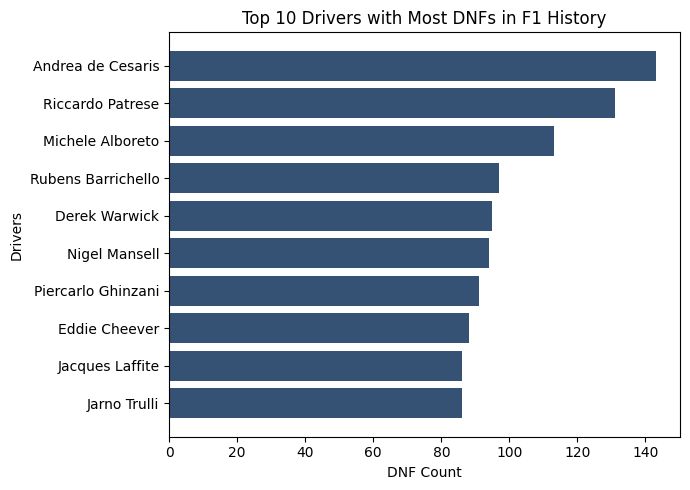

In [9]:
import matplotlib.pyplot as plt

top10 = dnf_counts.head(10).copy()
top10['full_name'] = top10['forename'] + ' ' + top10['surname']

fig, ax = plt.subplots(figsize=(7, 5))

ax.barh(top10['full_name'], top10['dnf_count'], color="#355275")
ax.invert_yaxis()
ax.set_xlabel("DNF Count")
ax.set_ylabel("Drivers")
ax.set_title("Top 10 Drivers with Most DNFs in F1 History")

plt.tight_layout()
plt.show()

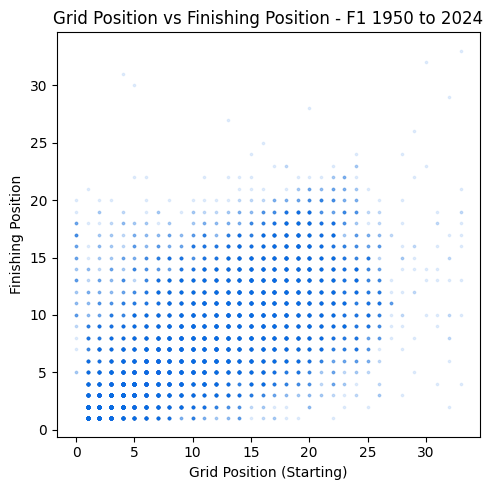

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

finished = df[df['position'].notna()].copy()

finished['grid'] = pd.to_numeric(finished['grid'], errors='coerce')
finished['position'] = pd.to_numeric(finished['position'], errors='coerce')

finished = finished.dropna(subset=['grid', 'position'])

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(finished['grid'], finished['position'], 
           alpha=0.1, color="#0A6BE1", s=3)

ax.set_xlabel("Grid Position (Starting)")
ax.set_ylabel("Finishing Position")
ax.set_title("Grid Position vs Finishing Position - F1 1950 to 2024")

plt.tight_layout()
plt.show()

In [11]:
import numpy as np

corr = finished['grid'].corr(finished['position'])
print(f"Correlation between grid and finish position: {corr:.3f}")

early = finished[finished['raceId'] <= 400]
modern = finished[finished['raceId'] > 400]

print(f"Early F1 correlation:  {early['grid'].corr(early['position']):.3f}")
print(f"Modern F1 correlation: {modern['grid'].corr(modern['position']):.3f}")

Correlation between grid and finish position: 0.638
Early F1 correlation:  0.682
Modern F1 correlation: 0.618
